Device: cpu

[1/4] Training source ANN...
  epoch 1/5  loss 0.1940
  epoch 2/5  loss 0.0561
  epoch 3/5  loss 0.0388
  epoch 4/5  loss 0.0303
  epoch 5/5  loss 0.0236
      ANN test accuracy: 98.94%

[2/4] Converting ANN -> SNN (99.9% robust-norm mode)...


100%|██████████| 8/8 [00:00<00:00,  9.41it/s]


[3/4] Sweeping timesteps T over [1, 2, 4, 8, 16, 32, 64, 128, 256] ...


      T=   1  ->  10.10%
      T=   2  ->  10.10%
      T=   4  ->  68.57%
      T=   8  ->  98.94%
      T=  16  ->  99.07%
      T=  32  ->  99.02%
      T=  64  ->  99.01%
      T= 128  ->  98.97%
      T= 256  ->  98.94%

[4/4] Plotting -> accuracy_vs_timesteps.png


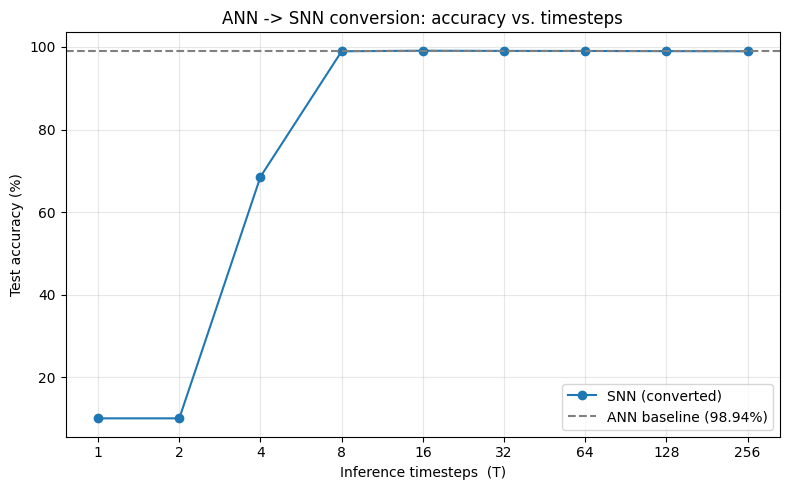


Done. The gap between the curve and the dashed line is the price of
spiking; more timesteps closes it but costs proportionally more compute.


In [ ]:

!pip install snntorch spikingjelly

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T_
import matplotlib.pyplot as plt

from spikingjelly.activation_based import ann2snn, functional

# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH        = 128
EPOCHS       = 5
LR           = 1e-3
T_MAX        = 256                                  # max inference timesteps
CHECKPOINTS  = [1, 2, 4, 8, 16, 32, 64, 128, 256]   # where we record accuracy
CALIB_BATCHES = 8                                   # batches used to scale thresholds

print(f"Device: {DEVICE}")

# ----------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------
transform = T_.Compose([
    T_.ToTensor(),
    T_.Normalize((0.1307,), (0.3081,)),
])

train_set = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=2)

# A small fixed subset is enough to calibrate activation ranges for conversion.
calib_subset = Subset(train_set, list(range(CALIB_BATCHES * BATCH)))
calib_loader = DataLoader(calib_subset, batch_size=BATCH, shuffle=False, num_workers=2)

# ----------------------------------------------------------------------
# Source ANN  (ReLU + AvgPool, no BN, no MaxPool)
# ----------------------------------------------------------------------
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.AvgPool2d(2),   # 28 -> 14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AvgPool2d(2),  # 14 -> 7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

# ----------------------------------------------------------------------
# Train the ANN
# ----------------------------------------------------------------------
def train_ann(model):
    model.to(DEVICE).train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(EPOCHS):
        running = 0.0
        for img, label in train_loader:
            img, label = img.to(DEVICE), label.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(img), label)
            loss.backward()
            opt.step()
            running += loss.item()
        print(f"  epoch {epoch + 1}/{EPOCHS}  loss {running / len(train_loader):.4f}")

@torch.no_grad()
def eval_ann(model):
    model.eval()
    correct = total = 0
    for img, label in test_loader:
        img, label = img.to(DEVICE), label.to(DEVICE)
        correct += (model(img).argmax(1) == label).sum().item()
        total   += label.numel()
    return correct / total

# ----------------------------------------------------------------------
# SNN inference: one pass to T_MAX, record accuracy at each checkpoint
# ----------------------------------------------------------------------
@torch.no_grad()
def sweep_snn(snn, loader, t_max, checkpoints):
    """Efficient sweep: accumulate output spikes across timesteps and snapshot
    accuracy at each checkpoint, instead of re-running from t=0 for every T."""
    snn.to(DEVICE).eval()
    cps = set(checkpoints)
    correct_at = {t: 0 for t in checkpoints}
    total = 0

    for img, label in loader:
        img, label = img.to(DEVICE), label.to(DEVICE)
        out = torch.zeros(img.shape[0], 10, device=DEVICE)
        for t in range(1, t_max + 1):
            out += snn(img)                  # constant input each step -> rate coding
            if t in cps:
                pred = out.argmax(1)
                correct_at[t] += (pred == label).sum().item()
        functional.reset_net(snn)            # clear membrane state before next batch
        total += label.numel()

    return {t: correct_at[t] / total for t in checkpoints}

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------
def plot_curve(results, ann_acc):
    Ts   = sorted(results)
    accs = [results[t] * 100 for t in Ts]

    plt.figure(figsize=(8, 5))
    plt.plot(Ts, accs, "o-", label="SNN (converted)")
    plt.axhline(ann_acc * 100, ls="--", color="gray", label=f"ANN baseline ({ann_acc * 100:.2f}%)")
    plt.xscale("log", base=2)
    plt.xticks(Ts, [str(t) for t in Ts])
    plt.xlabel("Inference timesteps  (T)")
    plt.ylabel("Test accuracy (%)")
    plt.title("ANN -> SNN conversion: accuracy vs. timesteps")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("accuracy_vs_timesteps.png", dpi=150)
    plt.show()

# ----------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------
def main():
    print("\n[1/4] Training source ANN...")
    ann = ConvNet()
    train_ann(ann)

    ann_acc = eval_ann(ann)
    print(f"      ANN test accuracy: {ann_acc * 100:.2f}%")

    print("\n[2/4] Converting ANN -> SNN (99.9% robust-norm mode)...")
    converter = ann2snn.Converter(mode="99.9%", dataloader=calib_loader)
    snn = converter(ann)

    print(f"\n[3/4] Sweeping timesteps T over {CHECKPOINTS} ...")
    results = sweep_snn(snn, test_loader, T_MAX, CHECKPOINTS)
    for t in CHECKPOINTS:
        print(f"      T={t:>4}  ->  {results[t] * 100:.2f}%")

    print("\n[4/4] Plotting -> accuracy_vs_timesteps.png")
    plot_curve(results, ann_acc)

    print("\nDone. The gap between the curve and the dashed line is the price of")
    print("spiking; more timesteps closes it but costs proportionally more compute.")


if __name__ == "__main__":
    main()